# Thermodynamics — Numerical Simulations

This notebook collects simulations for the main topics of Thermodynamics.
Each section is self-contained: it imports its own libraries and defines its own
helpers so that cells can be run independently.

**Topics covered:**
1.  PVT Diagram — Ideal Gas
2.  PVT Diagram — Van der Waals Gas & Maxwell Construction
3.  Carnot Cycle — P-V Diagram and Efficiency
4.  Adiabatic vs. Isothermal Expansion
5.  Maxwell–Boltzmann Speed Distribution
6.  1D Heat Conduction in a Thin Bar (FTCS)
7.  2D Heat Diffusion on a Rectangular Grid (FTCS)
8.  2D Diffusion on a Circular Drum (Bessel-mode decomposition)
9.  Newton's Law of Cooling vs. Stefan–Boltzmann Radiation
10. Brownian Motion and the Diffusion Coefficient

**Numerical methods used:**
- Forward-Time Centred-Space (FTCS) finite differences  (parabolic PDEs)
- Spectral / Bessel-mode decomposition                  (circular drum)
- Runge–Kutta 4 (RK4)                                  (ODEs)
- Monte-Carlo random walk                               (Brownian motion)

---
## 1. PVT Diagram — Ideal Gas

The ideal-gas equation of state is:

$$P = \frac{nRT}{V}$$

For $n = 1$ mol we plot isotherms $P(V)$ at several temperatures and the
corresponding 3-D surface $P(V,T)$.  The universal gas constant is
$R = 8.314\;\text{J mol}^{-1}\text{K}^{-1}$.

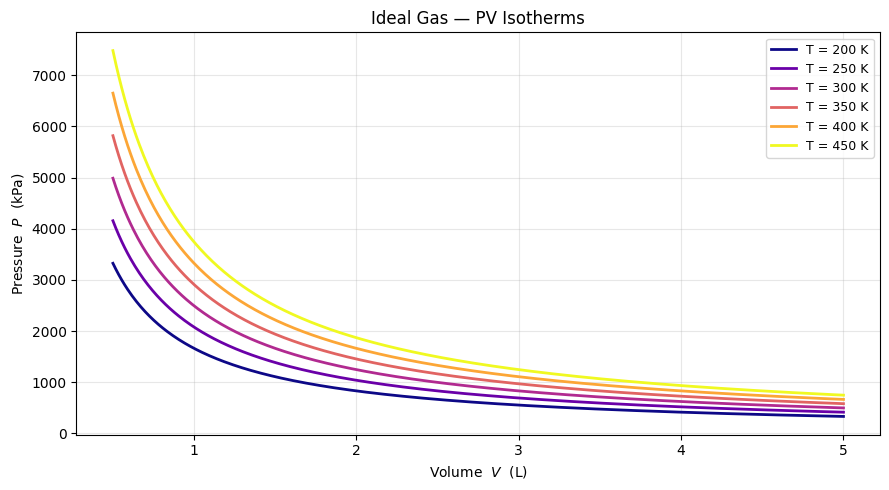

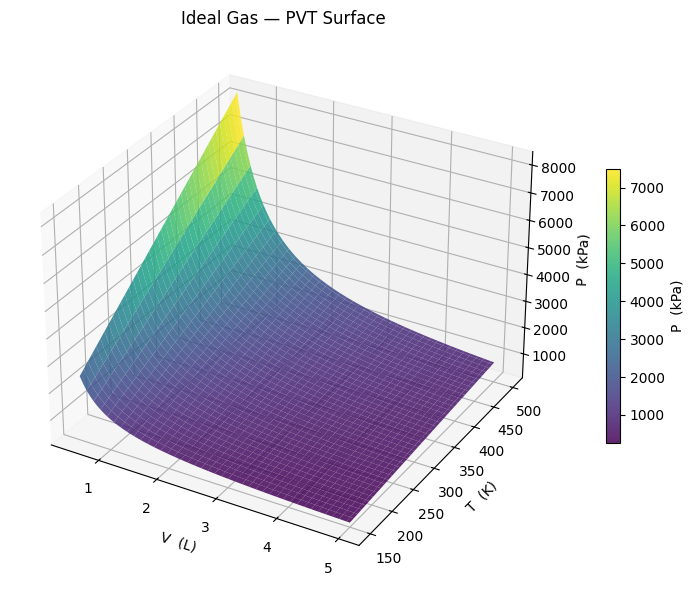

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # noqa: F401  (side-effect import for 3-D axes)

# --- Parameters ---
R   = 8.314          # universal gas constant (J / mol·K)
n   = 1.0            # amount of substance (mol)
V   = np.linspace(0.5e-3, 5e-3, 500)   # molar volume range (m³)
T_values = [200, 250, 300, 350, 400, 450]   # isotherm temperatures (K)

# --- Physics ---
def ideal_pressure(V_arr, T):
    """Ideal-gas pressure for n moles at temperature T over volume array V_arr."""
    return n * R * T / V_arr

# --- 2-D isotherm plot ---
fig, ax = plt.subplots(figsize=(9, 5))
cmap = plt.cm.plasma
for i, T in enumerate(T_values):
    P = ideal_pressure(V, T)
    ax.plot(V * 1e3, P / 1e3, color=cmap(i / (len(T_values) - 1)),
            lw=2, label=f"T = {T} K")
ax.set_xlabel("Volume  $V$  (L)")
ax.set_ylabel("Pressure  $P$  (kPa)")
ax.set_title("Ideal Gas — PV Isotherms")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

# --- 3-D PVT surface ---
V_grid = np.linspace(0.5e-3, 5e-3, 80)
T_grid = np.linspace(150, 500, 80)
VV, TT = np.meshgrid(V_grid, T_grid)
PP = n * R * TT / VV

fig3d = plt.figure(figsize=(10, 6))
ax3d  = fig3d.add_subplot(111, projection="3d")
surf  = ax3d.plot_surface(VV * 1e3, TT, PP / 1e3,
                          cmap="viridis", alpha=0.85, linewidth=0)
fig3d.colorbar(surf, ax=ax3d, shrink=0.5, label="P  (kPa)")
ax3d.set_xlabel("V  (L)")
ax3d.set_ylabel("T  (K)")
ax3d.set_zlabel("P  (kPa)")
ax3d.set_title("Ideal Gas — PVT Surface")
fig3d.tight_layout()
plt.show()

---
## 2. PVT Diagram — Van der Waals Gas & Maxwell Construction

The van der Waals equation of state corrects the ideal gas for molecular
volume ($b$) and intermolecular attraction ($a$):

$$\left(P + \frac{a}{V_m^2}\right)(V_m - b) = RT$$

Below the critical temperature the isotherm develops an unphysical
oscillation (spinodal region). The **Maxwell equal-area construction**
replaces it with a horizontal tie-line at the equilibrium vapour pressure
$P^*$ satisfying:

$$\int_{V_\text{liq}}^{V_\text{vap}} \left[P(V_m) - P^*\right] dV_m = 0$$

We use CO₂ parameters: $a = 0.3640\;\text{Pa m}^6\text{ mol}^{-2}$,
$b = 4.267\times10^{-5}\;\text{m}^3\text{ mol}^{-1}$,
$T_c = 304.2\;\text{K}$, $P_c = 7.39\;\text{MPa}$.

C:\Users\bruno\AppData\Local\Temp\ipykernel_36568\1763640990.py:27: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  val, _ = quad(integrand, Vm_lo, Vm_hi)
C:\Users\bruno\AppData\Local\Temp\ipykernel_36568\1763640990.py:27: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, _ = quad(integrand, Vm_lo, Vm_hi)
C:\Users\bruno\AppData\Local\Temp\ipykernel_36568\1763640990

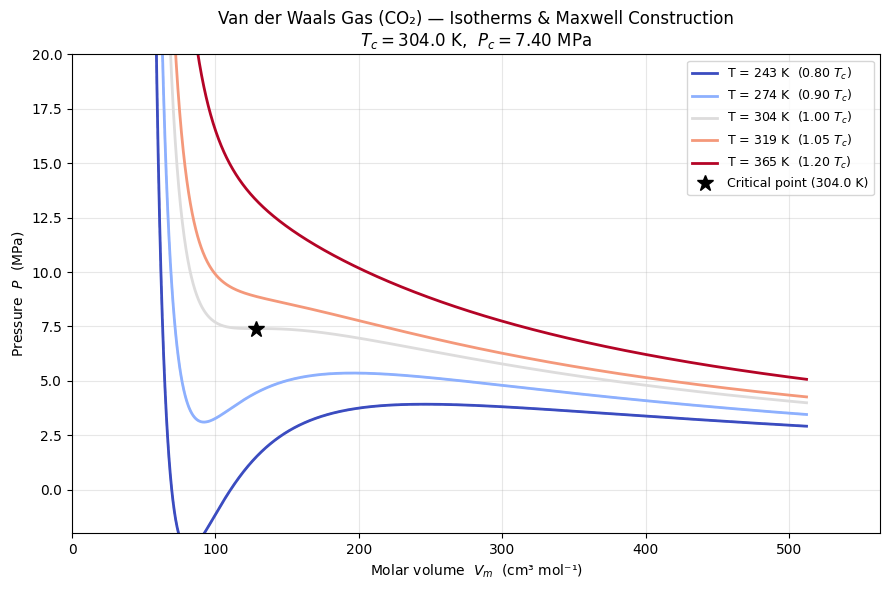

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.integrate import quad

# --- Van der Waals parameters for CO₂ ---
a_vdw = 0.3640        # Pa·m⁶·mol⁻²
b_vdw = 4.267e-5      # m³·mol⁻¹
R_vdw = 8.314
Tc    = 8 * a_vdw / (27 * R_vdw * b_vdw)   # critical temperature (K)
Pc    = a_vdw / (27 * b_vdw**2)              # critical pressure (Pa)
Vc    = 3 * b_vdw                            # critical molar volume (m³/mol)

def vdw_pressure(Vm, T):
    """Van der Waals pressure at molar volume Vm and temperature T."""
    return R_vdw * T / (Vm - b_vdw) - a_vdw / Vm**2

# --- Maxwell equal-area construction ---
def maxwell_Pstar(T, Vm_lo, Vm_hi):
    """
    Find the equilibrium pressure P* via the Maxwell construction by solving
        ∫_{Vm_lo}^{Vm_hi} [P(V) - P*] dV = 0
    using Brent's method.
    """
    def area_diff(Pstar):
        integrand = lambda V: vdw_pressure(V, T) - Pstar
        val, _ = quad(integrand, Vm_lo, Vm_hi)
        return val
    # P* must lie between the local minimum and maximum of the isotherm
    Vm_range = np.linspace(Vm_lo * 1.01, Vm_hi * 0.99, 2000)
    P_range  = vdw_pressure(Vm_range, T)
    Pmin, Pmax = P_range.min(), P_range.max()
    if Pmin >= Pmax:
        return None
    try:
        return brentq(area_diff, Pmin * 1.001, Pmax * 0.999)
    except ValueError:
        return None

# --- Isotherms ---
T_values_vdw = [0.80 * Tc, 0.90 * Tc, Tc, 1.05 * Tc, 1.20 * Tc]
Vm = np.linspace(b_vdw * 1.05, 12 * b_vdw, 1500)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.coolwarm

for i, T in enumerate(T_values_vdw):
    P = vdw_pressure(Vm, T) / 1e6    # convert to MPa
    color = cmap(i / (len(T_values_vdw) - 1))
    lbl   = f"T = {T:.0f} K  ({T/Tc:.2f} $T_c$)"

    if T < Tc:
        ax.plot(Vm * 1e6, P, color=color, lw=1.5, alpha=0.5, ls="--")
        # Locate spinodal bounds (local min/max in P)
        dP = np.diff(vdw_pressure(Vm, T))
        sign_changes = np.where(np.diff(np.sign(dP)))[0]
        if len(sign_changes) >= 2:
            Vm_liq = Vm[sign_changes[0] + 1]
            Vm_vap = Vm[sign_changes[1] + 1]
            Pstar  = maxwell_Pstar(T, Vm_liq * 0.5, Vm_vap * 1.5)
            if Pstar is not None:
                # Find liquid and vapour volumes at P*
                def residual(V): return vdw_pressure(V, T) - Pstar
                try:
                    Vl = brentq(residual, b_vdw * 1.01, Vm_liq)
                    Vv = brentq(residual, Vm_vap, Vm[-1] * 0.99)
                    # Physical isotherm with tie-line
                    mask_phys = (Vm <= Vl) | (Vm >= Vv)
                    ax.plot(Vm[mask_phys] * 1e6,
                            vdw_pressure(Vm[mask_phys], T) / 1e6,
                            color=color, lw=2, label=lbl)
                    ax.hlines(Pstar / 1e6, Vl * 1e6, Vv * 1e6,
                              color=color, lw=2, ls="-")
                except ValueError:
                    ax.plot(Vm * 1e6, P, color=color, lw=2, label=lbl)
    else:
        ax.plot(Vm * 1e6, P, color=color, lw=2, label=lbl)

ax.plot(Vc * 1e6, Pc / 1e6, "k*", ms=12, zorder=5, label=f"Critical point ({Tc:.1f} K)")
ax.set_xlim(0, Vm[-1] * 1.1 * 1e6)
ax.set_ylim(-2, 20)
ax.set_xlabel("Molar volume  $V_m$  (cm³ mol⁻¹)")
ax.set_ylabel("Pressure  $P$  (MPa)")
ax.set_title(f"Van der Waals Gas (CO₂) — Isotherms & Maxwell Construction\n"
             f"$T_c = {Tc:.1f}$ K,  $P_c = {Pc/1e6:.2f}$ MPa")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## 3. Carnot Cycle — P-V Diagram and Efficiency

The **Carnot cycle** is the most efficient possible heat engine operating
between two reservoirs at temperatures $T_H$ (hot) and $T_C$ (cold).
It consists of four reversible strokes for an ideal gas:

| Stroke | Process | Equation |
|--------|---------|----------|
| 1 → 2 | Isothermal expansion at $T_H$ | $PV = nRT_H$ |
| 2 → 3 | Adiabatic expansion | $PV^\gamma = \text{const}$ |
| 3 → 4 | Isothermal compression at $T_C$ | $PV = nRT_C$ |
| 4 → 1 | Adiabatic compression | $PV^\gamma = \text{const}$ |

The theoretical efficiency is $\eta = 1 - T_C/T_H$.

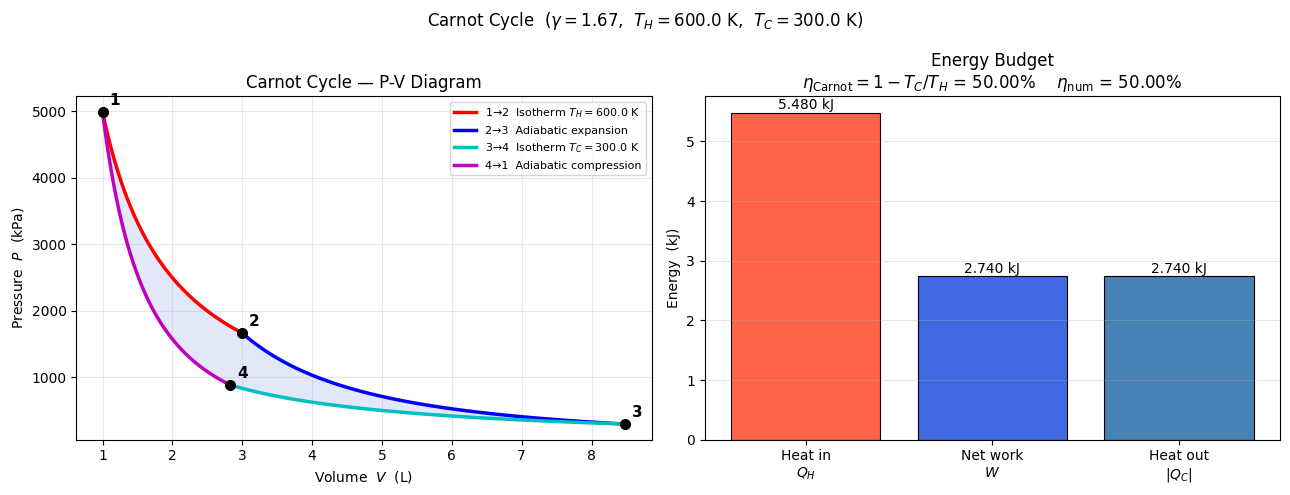

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
n_mol  = 1.0      # moles
R_c    = 8.314    # J / mol·K
gamma  = 5/3      # monatomic ideal gas (Ar, He)
T_H    = 600.0    # hot reservoir temperature (K)
T_C    = 300.0    # cold reservoir temperature (K)
V1     = 1.0e-3   # volume at state 1 (m³)  — start of hot isotherm

# --- Carnot state points ---
# State 1: (V1, P1) on T_H isotherm
P1 = n_mol * R_c * T_H / V1

# State 2: end of isothermal expansion (choose expansion ratio r = V2/V1)
r  = 3.0
V2 = r * V1
P2 = n_mol * R_c * T_H / V2

# State 3: end of adiabatic expansion (T drops from T_H to T_C)
# TV^(γ-1) = const  →  V3 = V2 * (T_H/T_C)^(1/(γ-1))
V3 = V2 * (T_H / T_C)**(1 / (gamma - 1))
P3 = n_mol * R_c * T_C / V3

# State 4: start of adiabatic compression (from T_C isotherm back to T_H)
# PV^γ = const from state 1: V4 = V1 * (T_H/T_C)^(1/(γ-1))
V4 = V1 * (T_H / T_C)**(1 / (gamma - 1))
P4 = n_mol * R_c * T_C / V4

# --- Build strokes ---
def isotherm(T, Va, Vb, N=300):
    V = np.linspace(Va, Vb, N)
    P = n_mol * R_c * T / V
    return V, P

def adiabat(Va, Pa, Vb, N=300):
    V = np.linspace(Va, Vb, N)
    P = Pa * (Va / V)**gamma
    return V, P

V12, P12 = isotherm(T_H, V1, V2)        # 1→2 hot isotherm
V23, P23 = adiabat(V2, P2, V3)          # 2→3 adiabatic expansion
V34, P34 = isotherm(T_C, V3, V4)        # 3→4 cold isotherm  (note: V4 < V3)
V41, P41 = adiabat(V4, P4, V1)          # 4→1 adiabatic compression

# --- Work and efficiency ---
def trapz_work(V_arr, P_arr):
    return np.trapezoid(P_arr, V_arr)

W12 = trapezoid_work(V12, P12)    # positive (expansion)
W23 = trapezoid_work(V23, P23)    # positive (expansion)
W34 = trapz_work(V34, P34)    # negative (compression, V decreasing)
W41 = trapz_work(V41, P41)    # negative (compression, V decreasing)

W_net      = W12 + W23 + W34 + W41
Q_in       = n_mol * R_c * T_H * np.log(V2 / V1)   # heat absorbed on hot isotherm
eta_num    = W_net / Q_in
eta_carnot = 1 - T_C / T_H

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.fill(np.concatenate([V12, V23, V34, V41]) * 1e3,
        np.concatenate([P12, P23, P34, P41]) / 1e3,
        alpha=0.15, color="royalblue")
ax.plot(V12 * 1e3, P12 / 1e3, "r-",  lw=2.5, label=f"1→2  Isotherm $T_H={T_H}$ K")
ax.plot(V23 * 1e3, P23 / 1e3, "b-",  lw=2.5, label="2→3  Adiabatic expansion")
ax.plot(V34 * 1e3, P34 / 1e3, "c-",  lw=2.5, label=f"3→4  Isotherm $T_C={T_C}$ K")
ax.plot(V41 * 1e3, P41 / 1e3, "m-",  lw=2.5, label="4→1  Adiabatic compression")
for Vi, Pi, lbl in zip([V1,V2,V3,V4],[P1,P2,P3,P4], ["1","2","3","4"]):
    ax.plot(Vi*1e3, Pi/1e3, "ko", ms=7, zorder=5)
    ax.annotate(lbl, (Vi*1e3, Pi/1e3), textcoords="offset points",
                xytext=(5,5), fontsize=11, fontweight="bold")
ax.set_xlabel("Volume  $V$  (L)")
ax.set_ylabel("Pressure  $P$  (kPa)")
ax.set_title("Carnot Cycle — P-V Diagram")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Energy flow Sankey-style bar chart
ax2 = axes[1]
labels = ["Heat in\n$Q_H$", "Net work\n$W$", "Heat out\n$|Q_C|$"]
Q_C_abs = Q_in - W_net
values  = [Q_in / 1e3, W_net / 1e3, Q_C_abs / 1e3]
colors  = ["tomato", "royalblue", "steelblue"]
bars    = ax2.bar(labels, values, color=colors, edgecolor="k", linewidth=0.8)
for bar, v in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, v + 0.01,
             f"{v:.3f} kJ", ha="center", va="bottom", fontsize=10)
ax2.set_ylabel("Energy  (kJ)")
ax2.set_title(f"Energy Budget\n"
              f"$\\eta_{{\\rm Carnot}} = 1-T_C/T_H$ = {eta_carnot:.2%}    "
              f"$\\eta_{{\\rm num}}$ = {eta_num:.2%}")
ax2.grid(True, alpha=0.3, axis="y")

fig.suptitle(f"Carnot Cycle  ($\\gamma = {gamma:.2f}$,  $T_H = {T_H}$ K,  $T_C = {T_C}$ K)",
             fontsize=12)
fig.tight_layout()
plt.show()

---
## 4. Adiabatic vs. Isothermal Expansion

For an ideal gas undergoing quasi-static expansion from volume $V_i$ to $V_f$:

| Process | Path in P-V plane | Work done |
|---------|-------------------|-----------|
| Isothermal | $P = nRT/V$ (hyperbola) | $W = nRT\ln(V_f/V_i)$ |
| Adiabatic  | $P V^\gamma = \text{const}$ (steeper) | $W = \frac{P_i V_i - P_f V_f}{\gamma - 1}$ |

The adiabat falls below the isotherm because no heat is supplied:
the gas cools as it expands, resulting in **less work** for the same volume
change and a lower final pressure.

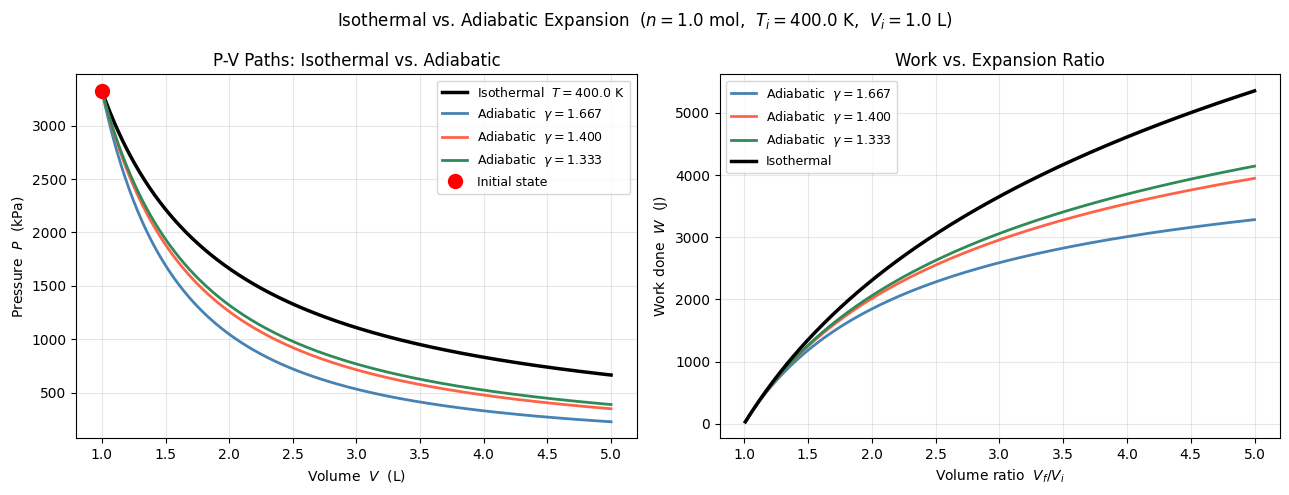

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
R_ad   = 8.314
n_ad   = 1.0
T_ad   = 400.0        # initial temperature (K)
V_i    = 1.0e-3       # initial volume (m³)
gamma_values = [5/3, 7/5, 4/3]   # monatomic, diatomic, triatomic
V_range = np.linspace(V_i, 5 * V_i, 500)

P_i = n_ad * R_ad * T_ad / V_i

def isothermal_P(V):
    return n_ad * R_ad * T_ad / V

def adiabatic_P(V, gam):
    return P_i * (V_i / V)**gam

def isothermal_work(Vf):
    return n_ad * R_ad * T_ad * np.log(Vf / V_i)

def adiabatic_work(Vf, gam):
    Pf = adiabatic_P(Vf, gam)
    return (P_i * V_i - Pf * Vf) / (gam - 1)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
P_iso = isothermal_P(V_range)
ax.plot(V_range * 1e3, P_iso / 1e3, "k-", lw=2.5,
        label=f"Isothermal  $T = {T_ad}$ K")
colors_ad = ["steelblue", "tomato", "seagreen"]
for gam, col in zip(gamma_values, colors_ad):
    P_ad = adiabatic_P(V_range, gam)
    ax.plot(V_range * 1e3, P_ad / 1e3, "-", color=col, lw=2,
            label=rf"Adiabatic  $\gamma = {gam:.3f}$")
ax.plot(V_i * 1e3, P_i / 1e3, "ro", ms=10, zorder=5, label="Initial state")
ax.set_xlabel("Volume  $V$  (L)")
ax.set_ylabel("Pressure  $P$  (kPa)")
ax.set_title("P-V Paths: Isothermal vs. Adiabatic")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Work comparison as function of expansion ratio
ax2 = axes[1]
Vf_range = np.linspace(V_i * 1.01, V_i * 5, 300)
W_iso = np.array([isothermal_work(Vf) for Vf in Vf_range])
for gam, col in zip(gamma_values, colors_ad):
    W_ad  = np.array([adiabatic_work(Vf, gam) for Vf in Vf_range])
    ax2.plot(Vf_range / V_i, W_ad, "-", color=col, lw=2,
             label=rf"Adiabatic  $\gamma = {gam:.3f}$")
ax2.plot(Vf_range / V_i, W_iso, "k-", lw=2.5, label="Isothermal")
ax2.set_xlabel("Volume ratio  $V_f / V_i$")
ax2.set_ylabel("Work done  $W$  (J)")
ax2.set_title("Work vs. Expansion Ratio")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle(f"Isothermal vs. Adiabatic Expansion  "
             f"($n = {n_ad}$ mol,  $T_i = {T_ad}$ K,  $V_i = {V_i*1e3:.1f}$ L)",
             fontsize=12)
fig.tight_layout()
plt.show()

---
## 5. Maxwell–Boltzmann Speed Distribution

The probability density for molecular speeds in an ideal gas at temperature $T$ is:

$$f(v) = 4\pi n \left(\frac{m}{2\pi k_B T}\right)^{3/2} v^2
         \exp\!\left(-\frac{mv^2}{2k_BT}\right)$$

Three characteristic speeds are:

$$v_p = \sqrt{\frac{2k_BT}{m}}, \quad
  \langle v \rangle = \sqrt{\frac{8k_BT}{\pi m}}, \quad
  v_{\rm rms} = \sqrt{\frac{3k_BT}{m}}$$

We compare distributions for **N₂** ($m = 28$ g/mol) at several temperatures,
and for different gases at the same temperature.

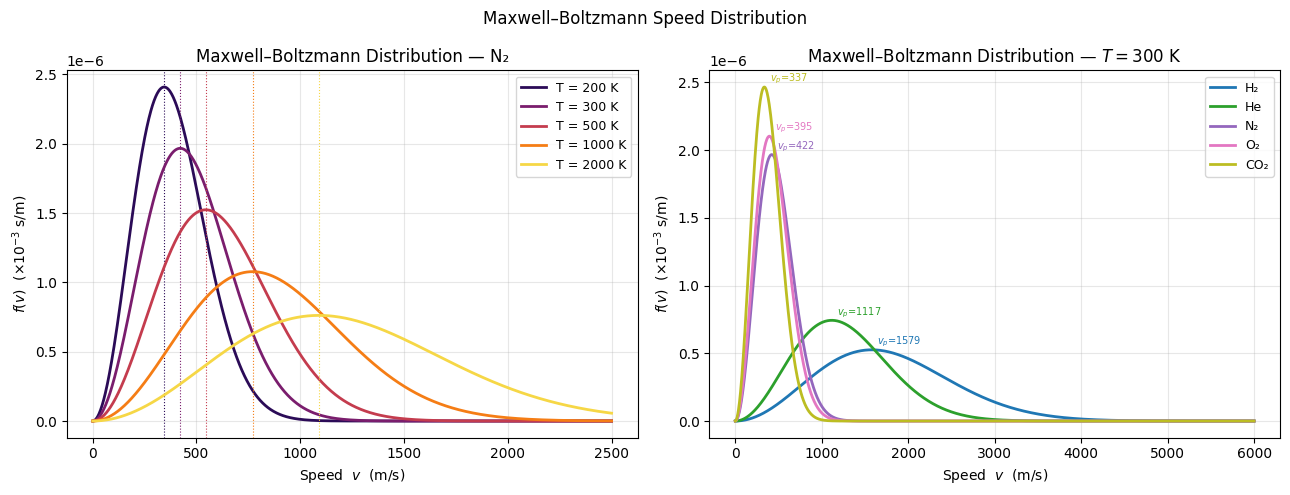

Characteristic speeds for N₂ at T = 300 K:
  Most probable  v_p   = 422.1 m/s
  Mean           <v>   = 476.3 m/s
  RMS            v_rms = 517.0 m/s


In [6]:
import numpy as np
import matplotlib.pyplot as plt

k_B  = 1.380649e-23   # Boltzmann constant (J/K)
N_A  = 6.02214076e23  # Avogadro's number (mol⁻¹)

def maxwell_boltzmann(v, m_kg, T):
    """Maxwell-Boltzmann speed distribution f(v)."""
    coeff = 4 * np.pi * (m_kg / (2 * np.pi * k_B * T))**1.5
    return coeff * v**2 * np.exp(-m_kg * v**2 / (2 * k_B * T))

def vp(m_kg, T):    return np.sqrt(2 * k_B * T / m_kg)
def vmean(m_kg, T): return np.sqrt(8 * k_B * T / (np.pi * m_kg))
def vrms(m_kg, T):  return np.sqrt(3 * k_B * T / m_kg)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: N₂ at different temperatures ---
m_N2    = 28e-3 / N_A   # kg per molecule
T_temps = [200, 300, 500, 1000, 2000]
v_max   = 2500
v_arr   = np.linspace(1, v_max, 1000)
cmap_T  = plt.cm.inferno

ax = axes[0]
for i, T in enumerate(T_temps):
    f = maxwell_boltzmann(v_arr, m_N2, T)
    col = cmap_T(0.15 + 0.75 * i / (len(T_temps) - 1))
    ax.plot(v_arr, f * 1e-3, color=col, lw=2, label=f"T = {T} K")
    # Mark most probable speed
    ax.axvline(vp(m_N2, T), color=col, lw=0.8, ls=":")
ax.set_xlabel("Speed  $v$  (m/s)")
ax.set_ylabel(r"$f(v)$  ($\times 10^{-3}$ s/m)")
ax.set_title("Maxwell–Boltzmann Distribution — N₂")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# --- Right: different gases at T = 300 K ---
T_ref = 300   # K
gases = {"H₂": 2e-3, "He": 4e-3, "N₂": 28e-3, "O₂": 32e-3, "CO₂": 44e-3}
v_max2 = 6000
v_arr2 = np.linspace(1, v_max2, 1500)
cmap_g = plt.cm.tab10

ax2 = axes[1]
for i, (name, M) in enumerate(gases.items()):
    m_mol = M / N_A
    f = maxwell_boltzmann(v_arr2, m_mol, T_ref)
    col = cmap_g(i / len(gases))
    ax2.plot(v_arr2, f * 1e-3, color=col, lw=2, label=name)
    vp_val = vp(m_mol, T_ref)
    vm_val = vmean(m_mol, T_ref)
    vr_val = vrms(m_mol, T_ref)
    ax2.annotate(f"$v_p$={vp_val:.0f}",
                 (vp_val, maxwell_boltzmann(vp_val, m_mol, T_ref) * 1e-3),
                 textcoords="offset points", xytext=(4, 4), fontsize=7, color=col)
ax2.set_xlabel("Speed  $v$  (m/s)")
ax2.set_ylabel(r"$f(v)$  ($\times 10^{-3}$ s/m)")
ax2.set_title(f"Maxwell–Boltzmann Distribution — $T = {T_ref}$ K")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

fig.suptitle("Maxwell–Boltzmann Speed Distribution", fontsize=12)
fig.tight_layout()
plt.show()

# --- Print characteristic speeds for N₂ at 300 K ---
print("Characteristic speeds for N₂ at T = 300 K:")
print(f"  Most probable  v_p   = {vp(m_N2, 300):.1f} m/s")
print(f"  Mean           <v>   = {vmean(m_N2, 300):.1f} m/s")
print(f"  RMS            v_rms = {vrms(m_N2, 300):.1f} m/s")

---
## 6. 1D Heat Conduction in a Thin Bar (FTCS)

The heat equation for a thin bar of length $L$ with thermal diffusivity
$\alpha = k / (\rho c_p)$ is:

$$\frac{\partial T}{\partial t} = \alpha \frac{\partial^2 T}{\partial x^2}$$

We discretise with the **Forward-Time Centred-Space (FTCS)** scheme:

$$T_i^{n+1} = T_i^n + r\left(T_{i+1}^n - 2T_i^n + T_{i-1}^n\right),
  \quad r = \frac{\alpha\,\Delta t}{(\Delta x)^2}$$

Stability requires $r \leq \tfrac{1}{2}$.  We test two sets of boundary and
initial conditions:

* **Case A** — Dirichlet: $T(0,t) = T_L$, $T(L,t) = T_R$;
  initial flat profile $T(x,0) = T_{\rm init}$.
* **Case B** — Neumann (insulated ends): $\partial T/\partial x = 0$ at both
  walls; initial Gaussian hot spot at the centre.

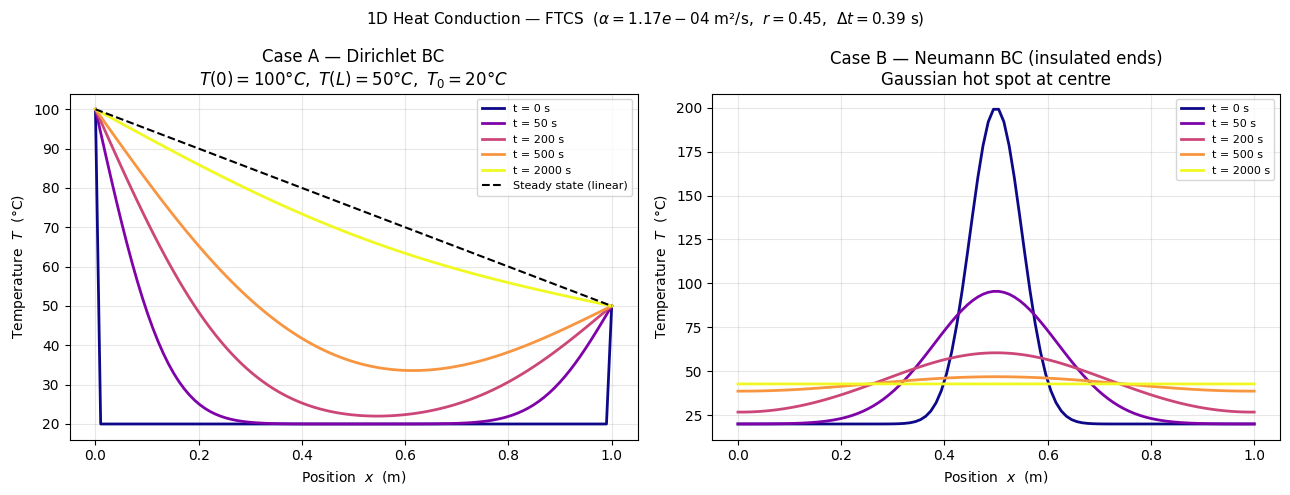

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
L_bar   = 1.0       # bar length (m)
alpha   = 1.17e-4   # thermal diffusivity of steel (m²/s)
Nx      = 100       # number of spatial grid points
dx      = L_bar / (Nx - 1)
r       = 0.45      # stability parameter  (r ≤ 0.5 required)
dt      = r * dx**2 / alpha
x_arr   = np.linspace(0, L_bar, Nx)

# --- Case A: Dirichlet BC ---
T_L, T_R, T_init = 100.0, 50.0, 20.0    # °C
T_A = np.full(Nx, T_init)
T_A[0]  = T_L
T_A[-1] = T_R

# Analytical steady state: linear profile
T_ss_A = T_L + (T_R - T_L) * x_arr / L_bar

t_snapshots = [0.0, 50.0, 200.0, 500.0, 2000.0]  # seconds
snap_A = {}
t = 0.0
snap_A[0.0] = T_A.copy()

def ftcs_step(T, r, bc="dirichlet"):
    T_new = T.copy()
    T_new[1:-1] = T[1:-1] + r * (T[2:] - 2*T[1:-1] + T[:-2])
    if bc == "dirichlet":
        T_new[0]  = T[0]
        T_new[-1] = T[-1]
    else:   # Neumann (zero-flux): ghost-cell symmetry
        T_new[0]  = T_new[1]
        T_new[-1] = T_new[-2]
    return T_new

# Run Case A
T_A_run = T_A.copy()
t = 0.0
remaining = sorted(t_snapshots[1:])
while remaining:
    T_A_run = ftcs_step(T_A_run, r, bc="dirichlet")
    t += dt
    if remaining and t >= remaining[0] - dt / 2:
        snap_A[remaining.pop(0)] = T_A_run.copy()

# --- Case B: Neumann BC + Gaussian IC ---
T_bg    = 20.0     # background temperature (°C)
T_peak  = 200.0    # peak temperature at centre (°C)
sigma_g = 0.05     # Gaussian width (m)
T_B = T_bg + (T_peak - T_bg) * np.exp(-0.5 * ((x_arr - L_bar/2) / sigma_g)**2)

snap_B  = {0.0: T_B.copy()}
T_B_run = T_B.copy()
remaining = sorted(t_snapshots[1:])
t = 0.0
while remaining:
    T_B_run = ftcs_step(T_B_run, r, bc="neumann")
    t += dt
    if remaining and t >= remaining[0] - dt / 2:
        snap_B[remaining.pop(0)] = T_B_run.copy()

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap_t = plt.cm.plasma
t_plot  = sorted(snap_A.keys())

for i, ts in enumerate(t_plot):
    col = cmap_t(i / (len(t_plot) - 1))
    axes[0].plot(x_arr, snap_A[ts], color=col, lw=2, label=f"t = {ts:.0f} s")
    axes[1].plot(x_arr, snap_B[ts], color=col, lw=2, label=f"t = {ts:.0f} s")

axes[0].plot(x_arr, T_ss_A, "k--", lw=1.5, label="Steady state (linear)")
axes[0].set_title("Case A — Dirichlet BC\n"
                  r"$T(0)=100°C,\ T(L)=50°C,\ T_0=20°C$")
axes[1].set_title("Case B — Neumann BC (insulated ends)\nGaussian hot spot at centre")
for ax in axes:
    ax.set_xlabel("Position  $x$  (m)")
    ax.set_ylabel("Temperature  $T$  (°C)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle(f"1D Heat Conduction — FTCS  "
             f"($\\alpha = {alpha:.2e}$ m²/s,  $r = {r}$,  $\\Delta t = {dt:.2f}$ s)",
             fontsize=11)
fig.tight_layout()
plt.show()

---
## 7. 2D Heat Diffusion on a Rectangular Grid (FTCS)

In two dimensions the heat equation becomes:

$$\frac{\partial T}{\partial t} =
  \alpha\left(\frac{\partial^2 T}{\partial x^2} +
              \frac{\partial^2 T}{\partial y^2}\right)$$

The FTCS update is:

$$T_{i,j}^{n+1} = T_{i,j}^n
  + r_x\!\left(T_{i+1,j}^n - 2T_{i,j}^n + T_{i-1,j}^n\right)
  + r_y\!\left(T_{i,j+1}^n - 2T_{i,j}^n + T_{i,j-1}^n\right)$$

Stability requires $r_x + r_y \leq \tfrac{1}{2}$.

**Setup:** A $1\;\text{m} \times 1\;\text{m}$ plate with a hot strip along the
bottom edge ($T = 100°C$), the top edge held at $0°C$, and the left/right
edges insulated.  Initial temperature is $20°C$ everywhere.

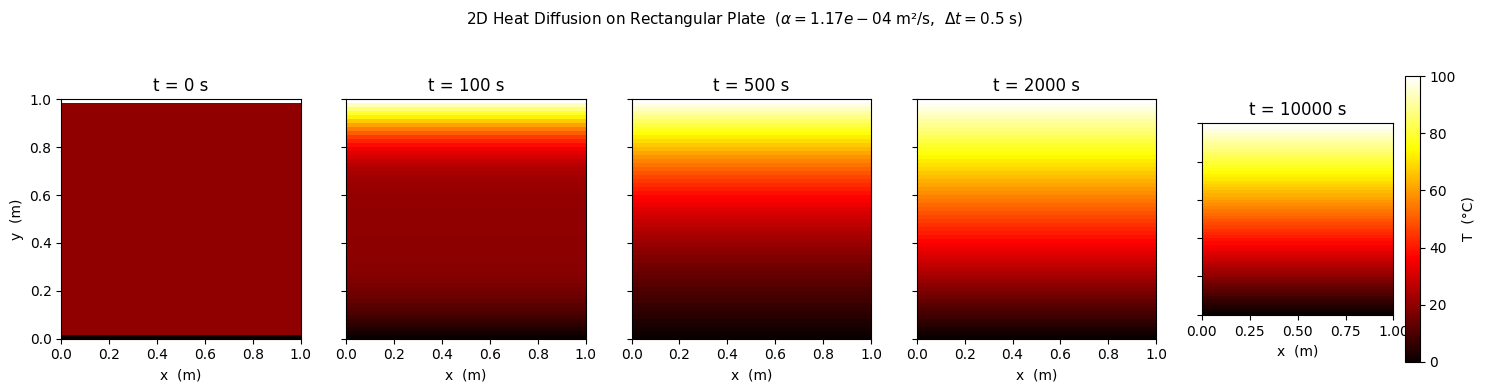

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# --- Grid parameters ---
Lx2, Ly2 = 1.0, 1.0      # plate dimensions (m)
Nx2, Ny2 = 60, 60         # grid resolution
dx2 = Lx2 / (Nx2 - 1)
dy2 = Ly2 / (Ny2 - 1)
alpha2 = 1.17e-4           # m²/s (steel)
r2     = 0.20              # r_x = r_y = r2  (r_x + r_y = 0.40 < 0.5 ✓)
dt2    = r2 * dx2**2 / alpha2

x2 = np.linspace(0, Lx2, Nx2)
y2 = np.linspace(0, Ly2, Ny2)

# --- Initial & boundary conditions ---
T2 = np.full((Ny2, Nx2), 20.0)
T2[-1, :]  = 100.0    # bottom edge (y = 0) — hot strip
T2[0,  :]  = 0.0      # top edge (y = Ly) — cold
# Left/right: Neumann (insulated) enforced at each step

def ftcs_step_2d(T, rx, ry):
    T_new = T.copy()
    T_new[1:-1, 1:-1] = (
        T[1:-1, 1:-1]
        + rx * (T[1:-1, 2:] - 2*T[1:-1, 1:-1] + T[1:-1, :-2])
        + ry * (T[2:,  1:-1] - 2*T[1:-1, 1:-1] + T[:-2, 1:-1])
    )
    # Dirichlet top / bottom
    T_new[0,  :] = 0.0
    T_new[-1, :] = 100.0
    # Neumann left / right (insulated)
    T_new[:, 0]  = T_new[:, 1]
    T_new[:, -1] = T_new[:, -2]
    return T_new

t_snap2  = [0, 100, 500, 2000, 10000]    # seconds
snaps2   = {0: T2.copy()}
T2_run   = T2.copy()
t2       = 0.0
remaining2 = sorted(t_snap2[1:])
while remaining2:
    T2_run = ftcs_step_2d(T2_run, r2, r2)
    t2 += dt2
    if remaining2 and t2 >= remaining2[0] - dt2 / 2:
        snaps2[remaining2.pop(0)] = T2_run.copy()

# --- Plot snapshots ---
fig, axes = plt.subplots(1, len(t_snap2), figsize=(15, 4), sharey=True)
for ax, ts in zip(axes, t_snap2):
    im = ax.imshow(snaps2[ts], origin="lower", extent=[0, Lx2, 0, Ly2],
                   vmin=0, vmax=100, cmap="hot", aspect="equal")
    ax.set_title(f"t = {ts} s")
    ax.set_xlabel("x  (m)")
axes[0].set_ylabel("y  (m)")
fig.colorbar(im, ax=axes[-1], label="T  (°C)", shrink=0.85)
fig.suptitle(f"2D Heat Diffusion on Rectangular Plate  "
             f"($\\alpha = {alpha2:.2e}$ m²/s,  $\\Delta t = {dt2:.1f}$ s)",
             fontsize=11)
fig.tight_layout()
plt.show()

---
## 8. 2D Diffusion on a Circular Drum (Bessel-Mode Decomposition)

The heat equation on a disk of radius $R$ with homogeneous Dirichlet boundary
conditions $T(R, \theta, t) = 0$ separates in polar coordinates.  The
eigenfunctions are products of Bessel functions and Fourier modes:

$$T(r,\theta,t) = \sum_{m=0}^{\infty}\sum_{n=1}^{\infty}
  J_m(\lambda_{mn} r)\left(A_{mn}\cos m\theta + B_{mn}\sin m\theta\right)
  e^{-\alpha\,\lambda_{mn}^2\,t}$$

where $\lambda_{mn} = z_{mn}/R$ and $z_{mn}$ is the $n$-th zero of $J_m$.
We truncate to a finite set of modes and project the initial condition
$T(r,\theta,0) = T_0\exp(-r^2/\sigma^2)$ (Gaussian hot spot) onto the basis.

Computing Bessel coefficients … done.


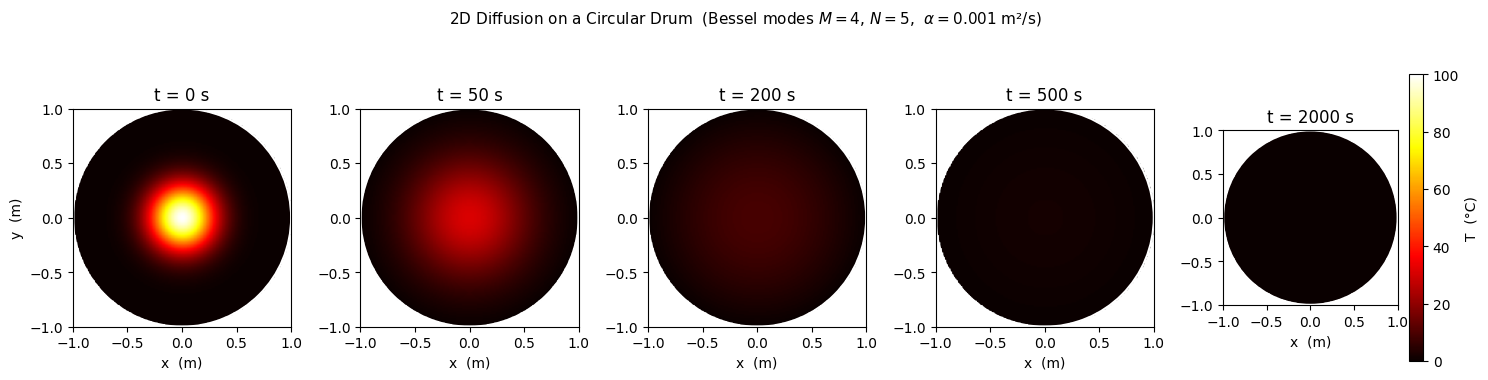

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn, jn_zeros

# --- Parameters ---
R_drum  = 1.0      # drum radius (m)
alpha_d = 1e-3     # thermal diffusivity (m²/s)
T0_d    = 100.0    # peak initial temperature (°C)
sigma_d = 0.3      # Gaussian width (m)
M_modes = 4        # Bessel orders m = 0 … M-1
N_modes = 5        # zeros per order

# --- Precompute Bessel zeros and lambda values ---
lam = {}   # lam[(m,n)] = z_mn / R
for m in range(M_modes):
    zeros = jn_zeros(m, N_modes)
    for n_idx, z in enumerate(zeros):
        lam[(m, n_idx + 1)] = z / R_drum

# --- Projection coefficients via numerical quadrature ---
Nr_q = 300
Ntheta_q = 360
r_q = np.linspace(0, R_drum, Nr_q)
theta_q = np.linspace(0, 2 * np.pi, Ntheta_q, endpoint=False)
RR_q, TH_q = np.meshgrid(r_q, theta_q)
XX_q = RR_q * np.cos(TH_q)
YY_q = RR_q * np.sin(TH_q)

T_IC = T0_d * np.exp(-(RR_q**2) / sigma_d**2)   # shape (Ntheta, Nr)

def inner_product_A(m, n):
    """<T0, J_m(λ_mn r) cos(mθ)> / norm²"""
    L = lam[(m, n)]
    phi = jn(m, L * RR_q) * np.cos(m * TH_q)   # (Ntheta, Nr)
    norm2 = np.trapezoid(
        np.trapezoid(phi**2 * RR_q, r_q, axis=1), theta_q
    )
    proj  = np.trapezoid(
        np.trapezoid(T_IC * phi * RR_q, r_q, axis=1), theta_q
    )
    return proj / norm2 if norm2 > 1e-12 else 0.0

def inner_product_B(m, n):
    """<T0, J_m(λ_mn r) sin(mθ)> / norm²  (zero by symmetry for m=0)"""
    if m == 0:
        return 0.0
    L = lam[(m, n)]
    phi = jn(m, L * RR_q) * np.sin(m * TH_q)
    norm2 = np.trapezoid(
        np.trapezoid(phi**2 * RR_q, r_q, axis=1), theta_q
    )
    proj  = np.trapezoid(
        np.trapezoid(T_IC * phi * RR_q, r_q, axis=1), theta_q
    )
    return proj / norm2 if norm2 > 1e-12 else 0.0

print("Computing Bessel coefficients …", end=" ", flush=True)
A_coeff = {}
B_coeff = {}
for m in range(M_modes):
    for n in range(1, N_modes + 1):
        A_coeff[(m, n)] = inner_product_A(m, n)
        B_coeff[(m, n)] = inner_product_B(m, n)
print("done.")

# --- Evaluate solution on Cartesian grid ---
Ngrid = 150
xg = np.linspace(-R_drum, R_drum, Ngrid)
yg = np.linspace(-R_drum, R_drum, Ngrid)
XX, YY = np.meshgrid(xg, yg)
RR = np.sqrt(XX**2 + YY**2)
TH = np.arctan2(YY, XX)
mask = RR <= R_drum

def T_drum(t):
    T_out = np.zeros((Ngrid, Ngrid))
    for m in range(M_modes):
        for n in range(1, N_modes + 1):
            L = lam[(m, n)]
            decay = np.exp(-alpha_d * L**2 * t)
            T_out += (A_coeff[(m, n)] * jn(m, L * RR) * np.cos(m * TH)
                      + B_coeff[(m, n)] * jn(m, L * RR) * np.sin(m * TH)) * decay
    T_out[~mask] = np.nan
    return T_out

# --- Plot snapshots ---
t_snaps_d = [0, 50, 200, 500, 2000]
fig, axes  = plt.subplots(1, len(t_snaps_d), figsize=(15, 4))
vmax_d     = T0_d

for ax, ts in zip(axes, t_snaps_d):
    T_snap = T_drum(ts)
    im = ax.imshow(T_snap, origin="lower",
                   extent=[-R_drum, R_drum, -R_drum, R_drum],
                   vmin=0, vmax=vmax_d, cmap="hot", aspect="equal")
    circle = plt.Circle((0, 0), R_drum, color="white", fill=False, lw=1.5)
    ax.add_patch(circle)
    ax.set_title(f"t = {ts} s")
    ax.set_xlabel("x  (m)")
axes[0].set_ylabel("y  (m)")
fig.colorbar(im, ax=axes[-1], label="T  (°C)", shrink=0.85)
fig.suptitle(f"2D Diffusion on a Circular Drum  "
             f"(Bessel modes $M={M_modes}$, $N={N_modes}$,  "
             f"$\\alpha = {alpha_d}$ m²/s)",
             fontsize=11)
fig.tight_layout()
plt.show()

---
## 9. Newton's Law of Cooling vs. Stefan–Boltzmann Radiation

Two classical models for an object losing heat to surroundings at $T_\infty$:

| Model | ODE | Regime |
|-------|-----|--------|
| Newton's law of cooling | $\dot{T} = -h A (T - T_\infty) / (m c_p)$ | convection-dominated |
| Stefan–Boltzmann | $\dot{T} = -\varepsilon\sigma A (T^4 - T_\infty^4) / (m c_p)$ | radiation-dominated |
| Combined | sum of both terms | realistic |

Newton's law predicts exponential decay; Stefan–Boltzmann gives a steeper
fall at high temperatures.  We integrate the combined ODE with RK4 for a
small steel sphere and compare the three models.

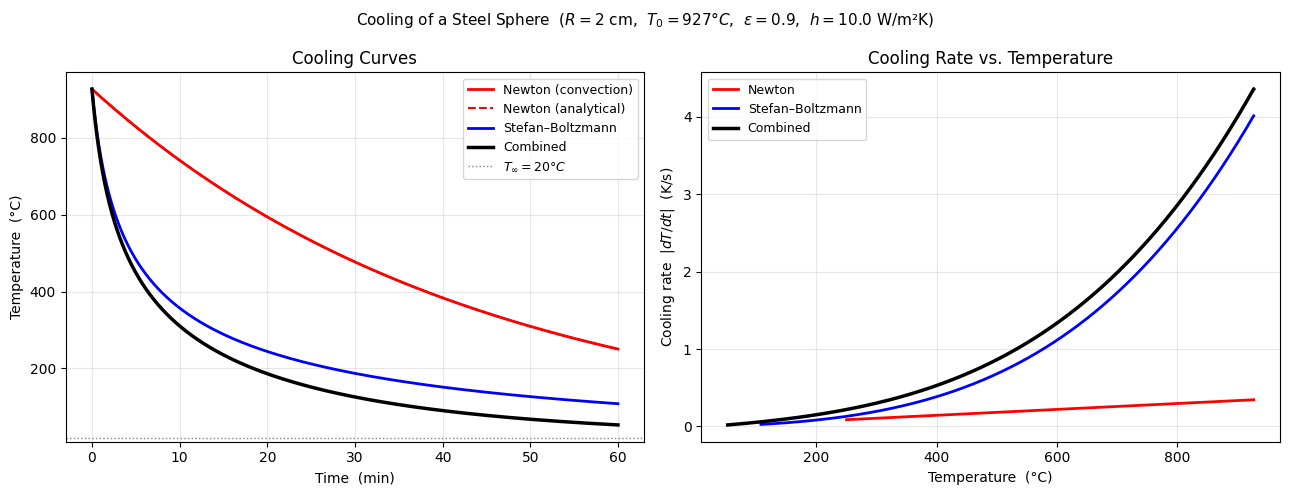

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
sigma_SB = 5.670374419e-8   # Stefan–Boltzmann constant (W/m²·K⁴)
epsilon  = 0.9              # emissivity of steel (black-painted)
h_conv   = 10.0             # convective heat-transfer coefficient (W/m²·K)
rho_s    = 7850.0           # density of steel (kg/m³)
cp_s     = 502.0            # specific heat of steel (J/kg·K)
R_sphere = 0.02             # sphere radius (m)
A_s      = 4 * np.pi * R_sphere**2    # surface area (m²)
V_s      = (4/3) * np.pi * R_sphere**3
m_s      = rho_s * V_s

T_inf    = 293.15    # ambient temperature (K)
T_start  = 1200.0    # initial temperature (K)  — freshly quenched sphere
tf_cool  = 3600.0    # total cooling time (s)
Nt_cool  = 50000

# --- Cooling ODEs ---
def dTdt_newton(T):
    return -h_conv * A_s * (T - T_inf) / (m_s * cp_s)

def dTdt_stefan(T):
    return -epsilon * sigma_SB * A_s * (T**4 - T_inf**4) / (m_s * cp_s)

def dTdt_combined(T):
    return dTdt_newton(T) + dTdt_stefan(T)

# --- RK4 integration ---
def rk4_cool(dTdt_func, T0, dt, Nt):
    T_arr = np.empty(Nt)
    T_arr[0] = T0
    T = T0
    for i in range(1, Nt):
        k1 = dTdt_func(T)
        k2 = dTdt_func(T + dt * k1 / 2)
        k3 = dTdt_func(T + dt * k2 / 2)
        k4 = dTdt_func(T + dt * k3)
        T += dt * (k1 + 2*k2 + 2*k3 + k4) / 6
        T_arr[i] = T
    return T_arr

dt_cool = tf_cool / (Nt_cool - 1)
t_cool  = np.linspace(0, tf_cool, Nt_cool)
T_newton   = rk4_cool(dTdt_newton,   T_start, dt_cool, Nt_cool)
T_stefan   = rk4_cool(dTdt_stefan,   T_start, dt_cool, Nt_cool)
T_combined = rk4_cool(dTdt_combined, T_start, dt_cool, Nt_cool)

# Analytical Newton solution
tau_newton = m_s * cp_s / (h_conv * A_s)
T_newton_analytic = T_inf + (T_start - T_inf) * np.exp(-t_cool / tau_newton)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
t_min = t_cool / 60   # convert to minutes

axes[0].plot(t_min, T_newton - 273.15,            "r-",  lw=2,   label="Newton (convection)")
axes[0].plot(t_min, T_newton_analytic - 273.15,   "r--", lw=1.5, label="Newton (analytical)")
axes[0].plot(t_min, T_stefan - 273.15,            "b-",  lw=2,   label="Stefan–Boltzmann")
axes[0].plot(t_min, T_combined - 273.15,          "k-",  lw=2.5, label="Combined")
axes[0].axhline(T_inf - 273.15, color="gray", ls=":", lw=1, label=f"$T_∞ = {T_inf-273.15:.0f}°C$")
axes[0].set_xlabel("Time  (min)")
axes[0].set_ylabel("Temperature  (°C)")
axes[0].set_title("Cooling Curves")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Instantaneous cooling rate (dT/dt)
dT_newton   = np.gradient(T_newton,   t_cool)
dT_stefan   = np.gradient(T_stefan,   t_cool)
dT_combined = np.gradient(T_combined, t_cool)
axes[1].plot(T_newton - 273.15,   np.abs(dT_newton),   "r-",  lw=2, label="Newton")
axes[1].plot(T_stefan - 273.15,   np.abs(dT_stefan),   "b-",  lw=2, label="Stefan–Boltzmann")
axes[1].plot(T_combined - 273.15, np.abs(dT_combined), "k-",  lw=2.5, label="Combined")
axes[1].set_xlabel("Temperature  (°C)")
axes[1].set_ylabel(r"Cooling rate  $|dT/dt|$  (K/s)")
axes[1].set_title("Cooling Rate vs. Temperature")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f"Cooling of a Steel Sphere  "
             f"($R = {R_sphere*100:.0f}$ cm,  $T_0 = {T_start-273.15:.0f}°C$,  "
             f"$\\varepsilon = {epsilon}$,  $h = {h_conv}$ W/m²K)",
             fontsize=11)
fig.tight_layout()
plt.show()

---
## 10. Brownian Motion and the Diffusion Coefficient

Einstein (1905) showed that a particle undergoing random thermal collisions
obeys the **diffusion equation** in the long-time limit, with mean-squared
displacement:

$$\langle r^2(t) \rangle = 2d\,D\,t$$

where $d$ is the spatial dimension and $D$ is the diffusion coefficient.
For a sphere of radius $a$ in a fluid of viscosity $\eta$ at temperature $T$:

$$D = \frac{k_B T}{6\pi\eta a} \quad \text{(Stokes–Einstein)}$$

We simulate $N$ independent walkers in 2-D taking Gaussian-distributed steps
and verify the $\langle r^2 \rangle \propto t$ scaling.

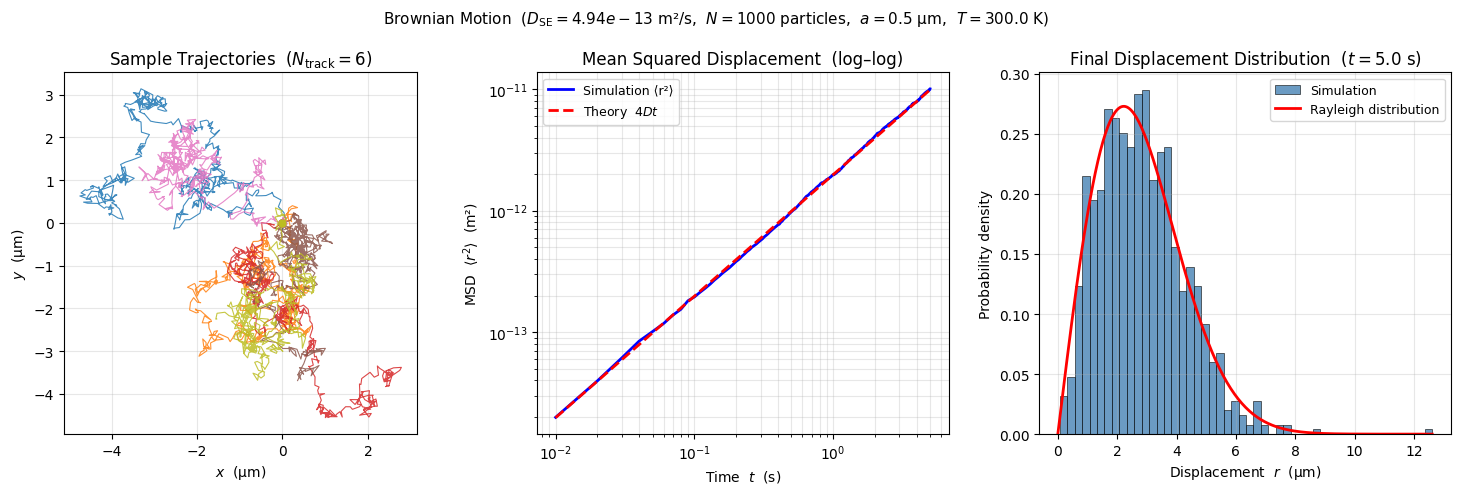


Stokes–Einstein diffusion coefficient:  D = 4.9379e-13 m²/s
Slope of MSD fit (should ≈ 4D = 1.9752e-12):  2.0046e-12 m²/s


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical parameters (pollen grain in water at 300 K) ---
k_B_bm  = 1.380649e-23    # J/K
T_bm    = 300.0            # temperature (K)
eta_bm  = 8.9e-4           # dynamic viscosity of water (Pa·s)
a_bm    = 0.5e-6           # particle radius (m) — 0.5 µm
D_bm    = k_B_bm * T_bm / (6 * np.pi * eta_bm * a_bm)    # Stokes–Einstein (m²/s)

# --- Simulation parameters ---
N_walkers = 1000     # number of independent particles
N_steps   = 500      # number of time steps
dt_bm     = 0.01     # time step (s)
step_std  = np.sqrt(2 * D_bm * dt_bm)   # std of each displacement component

rng = np.random.default_rng(seed=42)

# Positions: shape (N_walkers, 2)
pos = np.zeros((N_walkers, 2))

# Track a few individual trajectories
N_track = 6
tracks  = np.zeros((N_track, N_steps + 1, 2))

# MSD accumulator
msd     = np.zeros(N_steps + 1)
t_bm    = np.arange(N_steps + 1) * dt_bm

for step in range(N_steps):
    dxy  = rng.normal(0, step_std, size=(N_walkers, 2))
    pos += dxy
    r2   = np.sum(pos**2, axis=1)
    msd[step + 1] = r2.mean()
    if step + 1 <= N_steps:
        tracks[:, step + 1, :] = pos[:N_track, :]

# Theoretical MSD: 2 * d * D * t  (d = 2)
msd_theory = 4 * D_bm * t_bm

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: selected trajectories
cmap_bm = plt.cm.tab10
for i in range(N_track):
    axes[0].plot(tracks[i, :, 0] * 1e6, tracks[i, :, 1] * 1e6,
                 lw=0.8, color=cmap_bm(i / N_track), alpha=0.85)
    axes[0].plot(tracks[i, 0, 0] * 1e6, tracks[i, 0, 1] * 1e6,
                 "o", ms=5, color=cmap_bm(i / N_track))
axes[0].set_xlabel("$x$  (µm)")
axes[0].set_ylabel("$y$  (µm)")
axes[0].set_title(f"Sample Trajectories  ($N_{{\\rm track}} = {N_track}$)")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

# Panel 2: MSD vs time (log–log)
axes[1].loglog(t_bm[1:], msd[1:],       "b-",  lw=2,   label="Simulation ⟨r²⟩")
axes[1].loglog(t_bm[1:], msd_theory[1:], "r--", lw=2,   label="Theory  $4Dt$")
axes[1].set_xlabel("Time  $t$  (s)")
axes[1].set_ylabel("MSD  $\\langle r^2 \\rangle$  (m²)")
axes[1].set_title("Mean Squared Displacement  (log–log)")
axes[1].legend(fontsize=9)
axes[1].grid(True, which="both", alpha=0.3)

# Panel 3: displacement histogram at final step
r_final = np.sqrt(np.sum(pos**2, axis=1)) * 1e6   # µm
axes[2].hist(r_final, bins=50, density=True, color="steelblue",
             edgecolor="k", linewidth=0.5, alpha=0.8, label="Simulation")
# Theoretical Rayleigh distribution for 2-D diffusion
r_plot  = np.linspace(0, r_final.max(), 300)
sigma_r = np.sqrt(2 * D_bm * N_steps * dt_bm) * 1e6
f_rayleigh = (r_plot / sigma_r**2) * np.exp(-r_plot**2 / (2 * sigma_r**2))
axes[2].plot(r_plot, f_rayleigh, "r-", lw=2, label="Rayleigh distribution")
axes[2].set_xlabel("Displacement  $r$  (µm)")
axes[2].set_ylabel("Probability density")
axes[2].set_title(f"Final Displacement Distribution  ($t = {N_steps*dt_bm:.1f}$ s)")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

fig.suptitle(
    f"Brownian Motion  "
    f"($D_{{\\rm SE}} = {D_bm:.2e}$ m²/s,  $N = {N_walkers}$ particles,  "
    f"$a = {a_bm*1e6:.1f}$ µm,  $T = {T_bm}$ K)",
    fontsize=11
)
fig.tight_layout()
plt.show()

print(f"\nStokes–Einstein diffusion coefficient:  D = {D_bm:.4e} m²/s")
print(f"Slope of MSD fit (should ≈ 4D = {4*D_bm:.4e}):  "
      f"{np.polyfit(t_bm[1:], msd[1:], 1)[0]:.4e} m²/s")